# Example Flight Visualization

## Overview

This notebook demonstrates how the preprocessing modules are used to generate a vertical profile for an individual SAMBBA research flight. The harmonized datasets produced during the preprocessing stage are synchronized in time and used to compare the vertical distributions of organic aerosol (OA) concentration and aerosol light scattering.

## Workflow

1. Load the preprocessed datasets for a selected research flight.
2. Synchronize the observations from the different instruments using their common timestamps.
3. Extract the variables required for the analysis.
4. Generate a publication-quality vertical profile comparing organic aerosol concentration and aerosol scattering coefficient.

## Inputs

- Preprocessed flight datasets generated by the preprocessing modules.
- Matched observations from the FAAM core, AMS, SP2 and nephelometer datasets.

## Outputs

- A publication-quality vertical profile showing the relationship between organic aerosol concentration and aerosol scattering coefficient as a function of altitude for an individual research flight.

## Requirements

This notebook assumes that the preprocessing workflow has already been executed and that the processed datasets are available within the repository directory structure.

In [5]:
# This cell performs one step of the example flight visualization workflow.
# Comments throughout the notebook emphasize the scientific purpose of each processing stage.
import glob
import os
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from typing import List
from flights_io_commented  import get_matched_flights
from flight_processing_commented import process_flight

In [6]:
# Define the root directory containing the SAMBBA flight data downloaded
# from the CEDA archive. Each flight is stored in a separate subdirectory
# following the original archive structure.
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/"

# List of flight directories to be included in the analysis.
# These correspond to the SAMBBA research flights for which the required
# instrument datasets are available.
dirs = [
    "b732-sep-15", "b733-sep-16",
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20",
    "b738-sep-22", "b739-sep-23", "b742-sep-27", "b743-sep-27",
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02",
    "b749-oct-03",
]

# Search each flight directory and identify those containing a complete
# set of datasets required for the preprocessing workflow (AMS, SP2,
# nephelometer, FAAM core, cloud core, and flight summary files).
flights = get_matched_flights(base_dir, dirs)

# Print the location of the cloud-core files for each matched flight.
# This serves as a simple verification that all required files were
# successfully identified before proceeding with the analysis.
for flight in flights:
    print(flight.core_cloud)

Matched flights: 10
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core-cloud-phy_faam_20120918_v500_r0_b734.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core-cloud-phy_faam_20120920_v500_r0_b737.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b742.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b743.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b744.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b745.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2

In [7]:
def plot_vertical_profile_v2(
    ORG,
    ALT,
    TSC_GREEN,
):

    import matplotlib.pyplot as plt
    import numpy as np

    # Configure a publication-style layout suitable for single-column figures.
    # Font sizes and line widths are chosen to match the formatting used
    # throughout the manuscript.
    plt.rcParams.update({
        "font.size": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.0,
    })

    # Define a color palette consistent with the manuscript figures.
    color_oa = "#009E73"
    color_sca = "#E69F00"

    # Create the base figure using a single-column aspect ratio.
    fig, ax1 = plt.subplots(
        figsize=(3.5, 4.5),
        constrained_layout=True
    )

    # Plot the vertical distribution of organic aerosol (OA) concentration.
    # The bottom x-axis is reserved for the aerosol mass concentration.
    ax1.scatter(
        ORG,
        ALT,
        s=18,
        marker="o",
        color=color_oa,
        alpha=0.7,
        edgecolors="none",
        zorder=2
    )

    ax1.set_xlabel(
        "OA (µg m⁻³)",
        color=color_oa
    )

    ax1.tick_params(
        axis="x",
        colors=color_oa
    )

    ax1.spines["bottom"].set_color(color_oa)

    ax1.set_ylabel("Altitude (m)")
    ax1.set_xlim(0, 20)

    # Create a secondary x-axis to display aerosol scattering coefficients
    # on the same altitude profile without rescaling either variable.
    ax2 = ax1.twiny()

    ax2.scatter(
        TSC_GREEN,
        ALT,
        s=24,
        marker="x",
        color=color_sca,
        alpha=0.7,
        linewidths=0.8,
        zorder=3
    )

    ax2.set_xlabel(
        "σsca,green (Mm⁻¹)",
        color=color_sca
    )

    ax2.tick_params(
        axis="x",
        colors=color_sca
    )

    ax2.spines["top"].set_color(color_sca)

    ax2.set_xlim(0, 1200)

    # Set the altitude range automatically from the observations while
    # adding a small margin above the highest measurement.
    ymax = np.nanmax(ALT)

    ax1.set_ylim(
        0,
        ymax * 1.05
    )

    # Apply the final formatting. A light grid improves readability without
    # competing with the plotted observations.
    ax1.grid(
        alpha=0.2,
        linewidth=0.5
    )

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    return fig, (ax1, ax2)

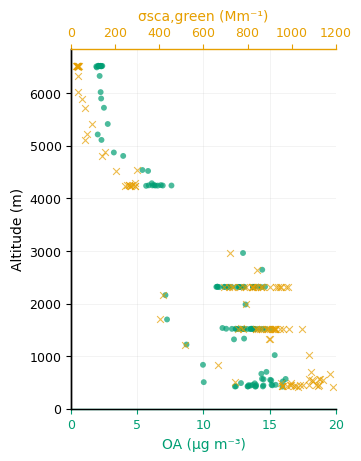

In [8]:
# Process the first matched flight and generate the datasets required
# for the subsequent analyses. The preprocessing routine applies the
# quality-control procedures and resamples all instruments to a common
# 1-minute temporal resolution.
for flight in flights[0:1]:

    out = process_flight(flight)

    # Retain only the timestamps shared by the FAAM core, AMS and SP2
    # datasets. Restricting the analysis to concurrent measurements
    # ensures that all variables describe the same atmospheric conditions.
    common_times = np.intersect1d(out.core.data_point.values, out.ams.time.values)
    common_times = np.intersect1d(common_times, out.sp2.time.values)

    # Extract the synchronized observations from each dataset.
    core_file_matched = out.core.sel(data_point=common_times)
    ams_resampled_matched = out.ams.sel(time=common_times)
    resampled_neph_matched = out.neph.sel(time=common_times)

    # Retrieve the variables required to construct the vertical profile.
    Height = core_file_matched["GPS_ALT"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    # Cabin conditions
    CAB_PRES = core_file_matched["CAB_PRES"].values.squeeze()      # hPa
    CAB_TEMP = core_file_matched["CAB_TEMP"].values.squeeze() + 273.15  # K
    # STP reference
    P_STP = 1013.25   # hPa
    T_STP = 273.15    # K
    
    conversion_factor = (CAB_PRES / P_STP) * (T_STP / CAB_TEMP)
    #AMS variable
    ORG = ams_resampled_matched["ORG"].values * conversion_factor  # Convert to ATP conditions

    # Generate a vertical profile comparing organic aerosol (OA)
    # concentration with the aerosol scattering coefficient measured
    # at the green wavelength.
    fig, axes = plot_vertical_profile_v2(
        ORG=ORG,
        ALT=Height,
        TSC_GREEN=TSC_green * 10e6,   # Convert from m⁻¹ to Mm⁻¹
    )